In [11]:
# Rainfall Pattern Analysis in India

In [ ]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [12]:
# Creating Folders to Save Plots

output_folder = 'rainfall_project_outputs'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print('Output folder created')

Output folder created


In [13]:
# Loading Datasets

rainfall = pd.read_csv('rainfall in india 1901-2015.csv')
district = pd.read_csv('district wise rainfall normal.csv')

print('Datasets loaded')

Datasets loaded


In [14]:
# Overview of the Datasets

print('Rainfall Dataset Shape:', rainfall.shape)
print('District Dataset Shape:', district.shape)

print('Rainfall Dataset Info:')
print(rainfall.info())

print('First 5 rows:')
print(rainfall.head())

Rainfall Dataset Shape: (4116, 19)
District Dataset Shape: (641, 19)
Rainfall Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4116 entries, 0 to 4115
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4116 non-null   object 
 1   YEAR         4116 non-null   int64  
 2   JAN          4112 non-null   float64
 3   FEB          4113 non-null   float64
 4   MAR          4110 non-null   float64
 5   APR          4112 non-null   float64
 6   MAY          4113 non-null   float64
 7   JUN          4111 non-null   float64
 8   JUL          4109 non-null   float64
 9   AUG          4112 non-null   float64
 10  SEP          4110 non-null   float64
 11  OCT          4109 non-null   float64
 12  NOV          4105 non-null   float64
 13  DEC          4106 non-null   float64
 14  ANNUAL       4090 non-null   float64
 15  Jan-Feb      4110 non-null   float64
 16  Mar-May      4107 non-null   float64
 17

In [15]:
# Checking Missing Values

print('Missing values in rainfall dataset:')
print(rainfall.isnull().sum())

print('Missing values in district dataset:')
print(district.isnull().sum())

Missing values in rainfall dataset:
SUBDIVISION     0
YEAR            0
JAN             4
FEB             3
MAR             6
APR             4
MAY             3
JUN             5
JUL             7
AUG             4
SEP             6
OCT             7
NOV            11
DEC            10
ANNUAL         26
Jan-Feb         6
Mar-May         9
Jun-Sep        10
Oct-Dec        13
dtype: int64
Missing values in district dataset:
STATE_UT_NAME    0
DISTRICT         0
JAN              0
FEB              0
MAR              0
APR              0
MAY              0
JUN              0
JUL              0
AUG              0
SEP              0
OCT              0
NOV              0
DEC              0
ANNUAL           0
Jan-Feb          0
Mar-May          0
Jun-Sep          0
Oct-Dec          0
dtype: int64


In [16]:
# Filling Missing Values with Mean

rainfall = rainfall.fillna(rainfall.select_dtypes(include=np.number).mean())
print('Missing values handled')

Missing values handled


In [17]:
# Creating Annual Rainfall Column

monthly_cols = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

rainfall['ANNUAL_TOTAL'] = rainfall[monthly_cols].sum(axis=1)
print(rainfall[['YEAR','ANNUAL_TOTAL']].head())

   YEAR  ANNUAL_TOTAL
0  1901        3373.2
1  1902        3520.7
2  1903        2957.4
3  1904        3079.6
4  1905        2566.7


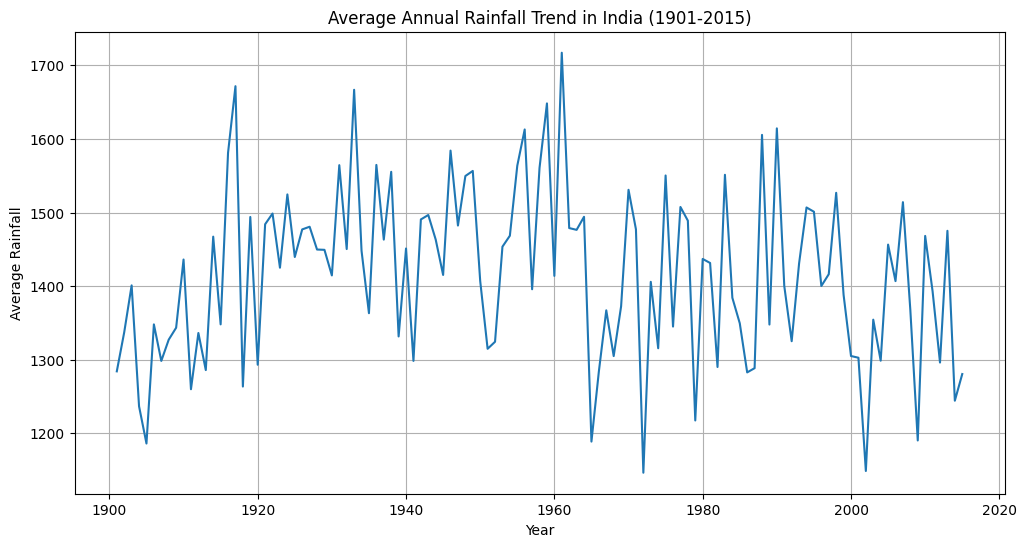

In [18]:
# Annual Rainfall Trend Over Years

yearly_rainfall = rainfall.groupby('YEAR')['ANNUAL_TOTAL'].mean()

plt.figure(figsize=(12,6))

plt.plot(yearly_rainfall.index, yearly_rainfall.values)

plt.title('Average Annual Rainfall Trend in India (1901-2015)')

plt.xlabel('Year')

plt.ylabel('Average Rainfall')

plt.grid(True)

plt.savefig(f'{output_folder}/annual_rainfall_trend.png', bbox_inches='tight')

plt.show()

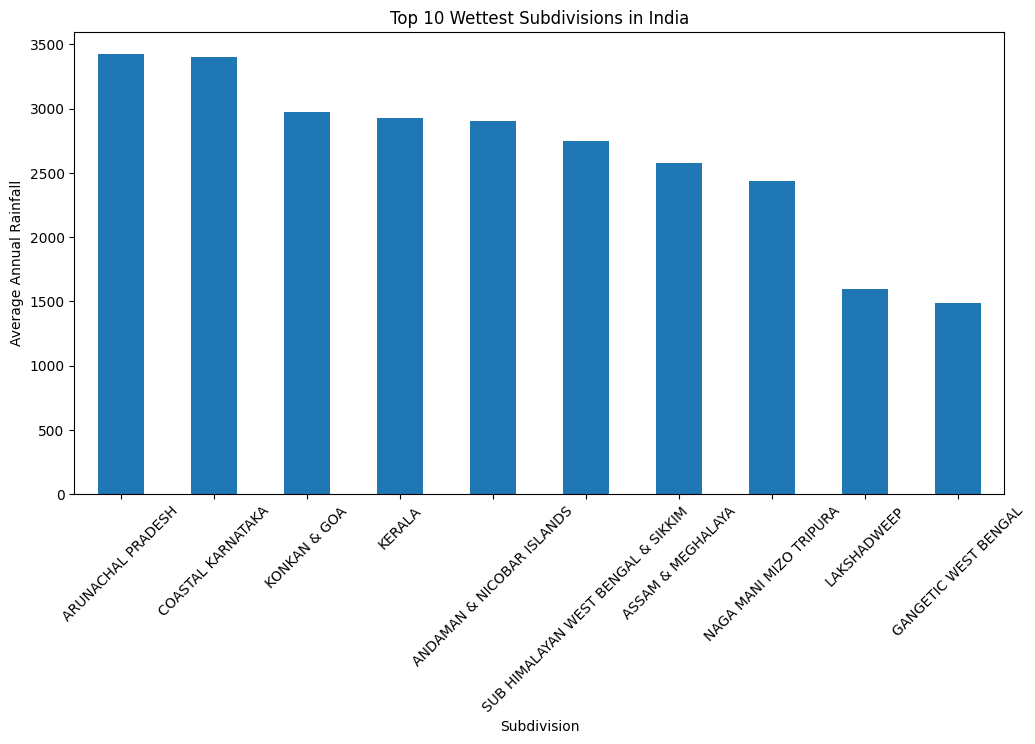

In [19]:
# Top 10 Wettest Subdivisions

wettest = rainfall.groupby('SUBDIVISION')['ANNUAL_TOTAL'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

wettest.plot(kind='bar')

plt.title('Top 10 Wettest Subdivisions in India')

plt.xlabel('Subdivision')

plt.ylabel('Average Annual Rainfall')

plt.xticks(rotation=45)

plt.savefig(f'{output_folder}/top_10_wettest.png', bbox_inches='tight')

plt.show()

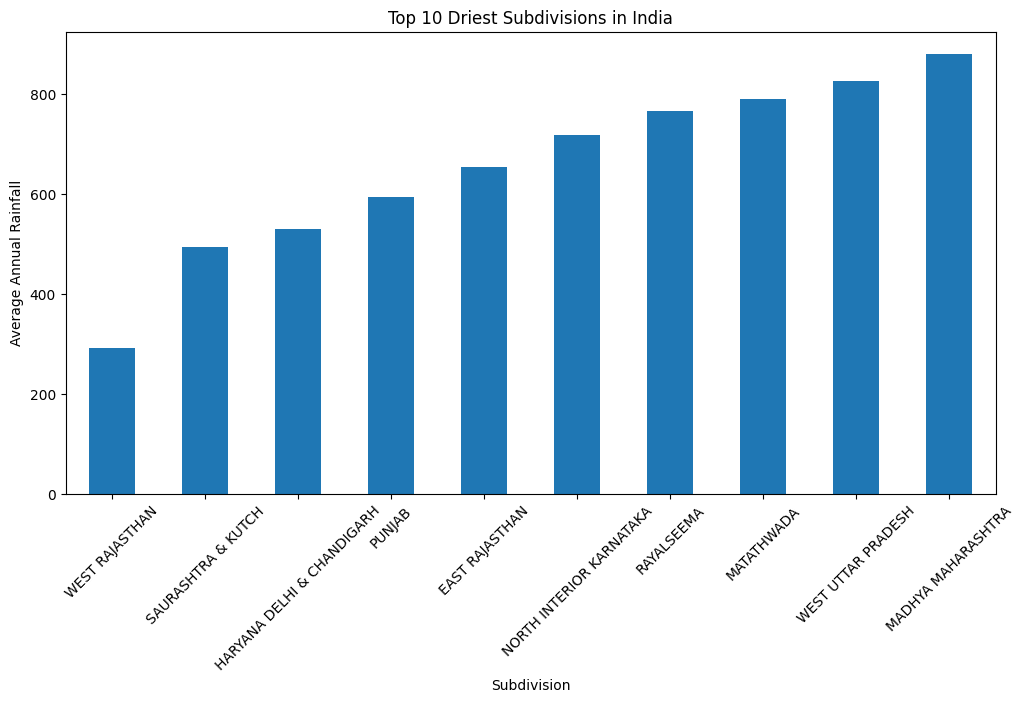

In [20]:
# Top 10 Driest Subdivisions

driest = rainfall.groupby('SUBDIVISION')['ANNUAL_TOTAL'].mean().sort_values().head(10)

plt.figure(figsize=(12,6))

driest.plot(kind='bar')

plt.title('Top 10 Driest Subdivisions in India')

plt.xlabel('Subdivision')

plt.ylabel('Average Annual Rainfall')

plt.xticks(rotation=45)

plt.savefig(f'{output_folder}/top_10_driest.png', bbox_inches='tight')

plt.show()

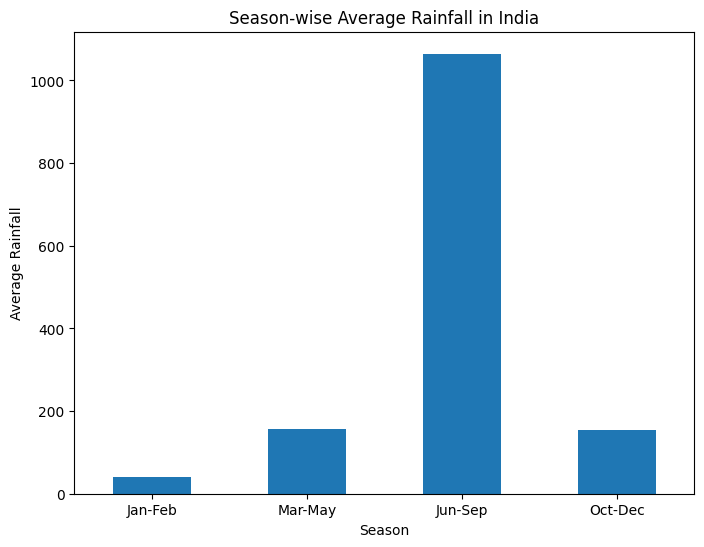

In [21]:
# Seasonal Rainfall Comparison

season_cols = ['Jan-Feb','Mar-May','Jun-Sep','Oct-Dec']

season_avg = rainfall[season_cols].mean()

plt.figure(figsize=(8,6))

season_avg.plot(kind='bar')

plt.title('Season-wise Average Rainfall in India')

plt.xlabel('Season')

plt.ylabel('Average Rainfall')

plt.xticks(rotation=0)

plt.savefig(f'{output_folder}/seasonal_rainfall.png', bbox_inches='tight')

plt.show()

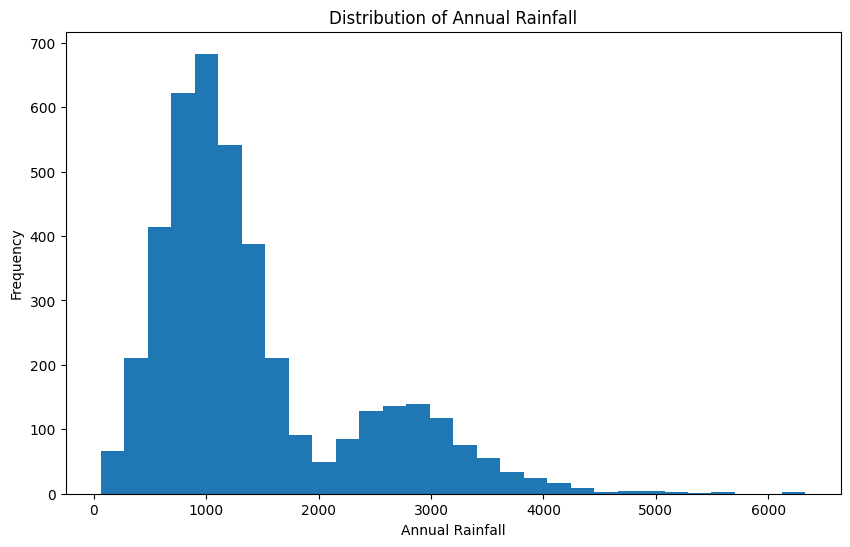

In [24]:
# Histogram of Annual Rainfall Distribution

plt.figure(figsize=(10,6))

plt.hist(rainfall['ANNUAL_TOTAL'], bins=30)

plt.title('Distribution of Annual Rainfall')

plt.xlabel('Annual Rainfall')

plt.ylabel('Frequency')

plt.savefig(f'{output_folder}/rainfall_distribution.png', bbox_inches='tight')

plt.show()

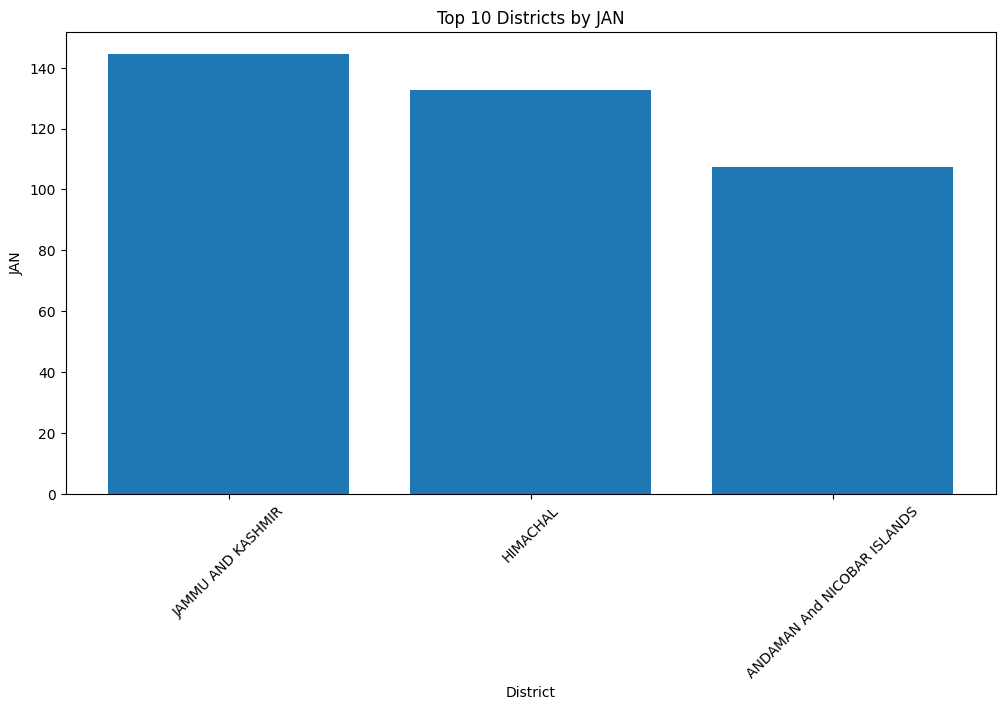

In [25]:
# District wise Comparison

district_numeric = district.select_dtypes(include=np.number)
first_col = district_numeric.columns[0]

top_districts = district.sort_values(by=first_col, ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(top_districts.iloc[:,0].astype(str), top_districts[first_col])

plt.title(f'Top 10 Districts by {first_col}')

plt.xlabel('District')

plt.ylabel(first_col)

plt.xticks(rotation=45)

plt.savefig(f'{output_folder}/district_comparison.png', bbox_inches='tight')

plt.show()

In [26]:
# Descriptive Statistics

print('Summary Statistics:')
print(rainfall.describe())

Summary Statistics:
              YEAR          JAN          FEB          MAR          APR  \
count  4116.000000  4116.000000  4116.000000  4116.000000  4116.000000   
mean   1958.218659    18.957320    21.805325    27.359197    43.127432   
std      33.140898    33.569044    35.896396    46.925176    67.798192   
min    1901.000000     0.000000     0.000000     0.000000     0.000000   
25%    1930.000000     0.600000     0.600000     1.000000     3.000000   
50%    1958.000000     6.000000     6.700000     7.900000    15.700000   
75%    1987.000000    22.125000    26.800000    31.225000    49.825000   
max    2015.000000   583.700000   403.500000   605.600000   595.100000   

               MAY          JUN          JUL          AUG          SEP  \
count  4116.000000  4116.000000  4116.000000  4116.000000  4116.000000   
mean     85.745417   230.234444   347.214334   290.263497   197.361922   
std     123.189974   234.568120   269.310313   188.678707   135.309591   
min       0.00000

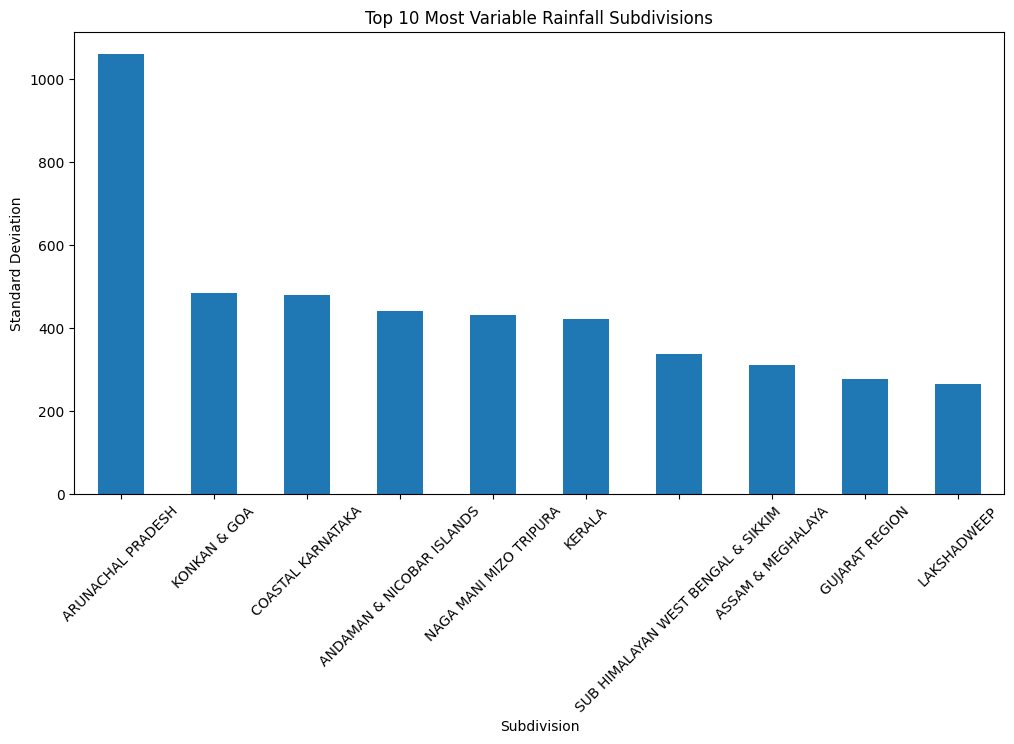

In [27]:
# Rainfall Variability Analysis

rainfall_variability = rainfall.groupby('SUBDIVISION')['ANNUAL_TOTAL'].std().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

rainfall_variability.plot(kind='bar')

plt.title('Top 10 Most Variable Rainfall Subdivisions')

plt.xlabel('Subdivision')

plt.ylabel('Standard Deviation')

plt.xticks(rotation=45)

plt.savefig(f'{output_folder}/rainfall_variability.png', bbox_inches='tight')

plt.show()

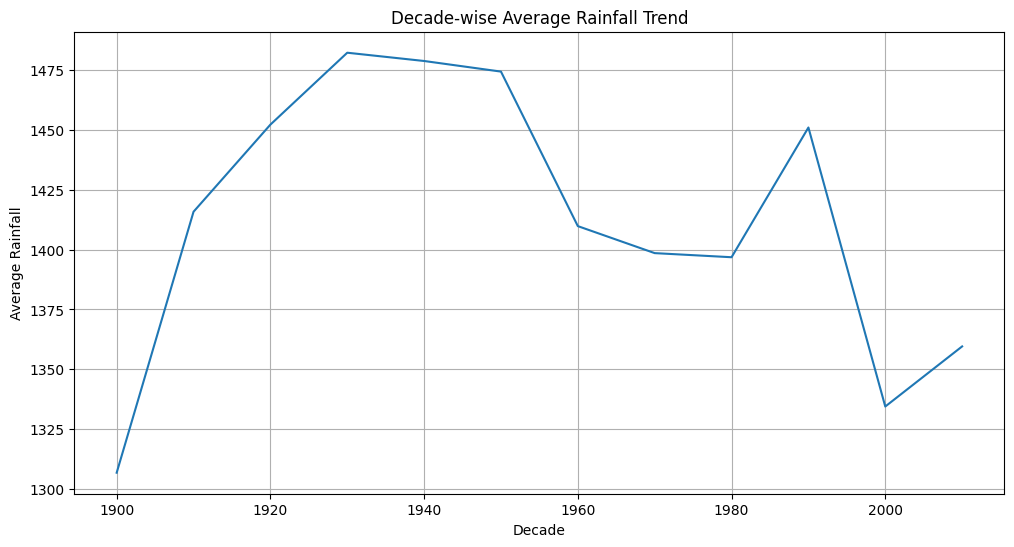

In [28]:
# Decade-wise Rainfall Analysis

rainfall['DECADE'] = (rainfall['YEAR'] // 10) * 10

decade_avg = rainfall.groupby('DECADE')['ANNUAL_TOTAL'].mean()

plt.figure(figsize=(12,6))

plt.plot(decade_avg.index, decade_avg.values)

plt.title('Decade-wise Average Rainfall Trend')

plt.xlabel('Decade')

plt.ylabel('Average Rainfall')

plt.grid(True)

plt.savefig(f'{output_folder}/decade_wise_rainfall.png', bbox_inches='tight')

plt.show()

Correlation between Monsoon and Annual Rainfall: 0.9425931447697543


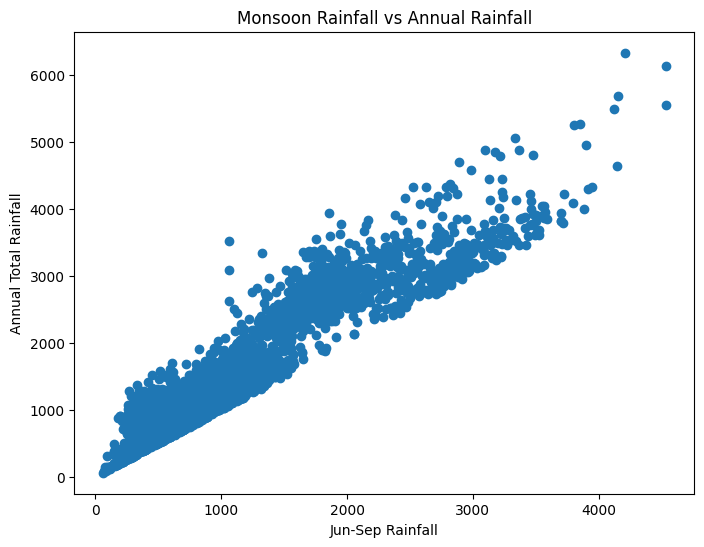

In [29]:
# Monsoon vs Annual Rainfall Comparison

# Monsoon dependency

correlation = rainfall['Jun-Sep'].corr(rainfall['ANNUAL_TOTAL'])
print('Correlation between Monsoon and Annual Rainfall:', correlation)

plt.figure(figsize=(8,6))

plt.scatter(rainfall['Jun-Sep'], rainfall['ANNUAL_TOTAL'])

plt.title('Monsoon Rainfall vs Annual Rainfall')

plt.xlabel('Jun-Sep Rainfall')

plt.ylabel('Annual Total Rainfall')

plt.savefig(f'{output_folder}/monsoon_correlation.png', bbox_inches='tight')

plt.show()

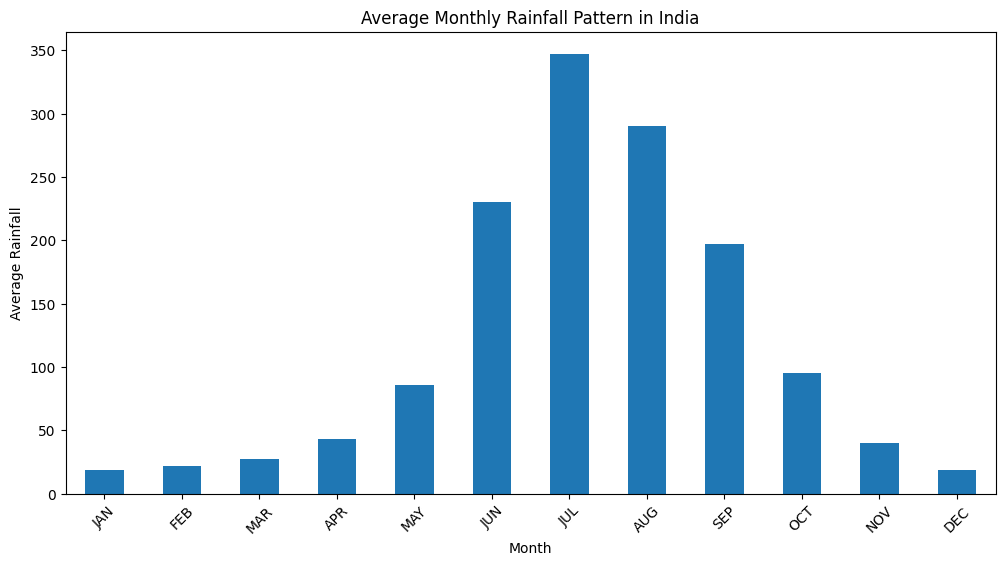

In [31]:
# Monthly Average Rainfall Pattern

# Identifying rainfall concentration months
monthly_cols = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
monthly_avg = rainfall[monthly_cols].mean()

plt.figure(figsize=(12,6))

monthly_avg.plot(kind='bar')

plt.title('Average Monthly Rainfall Pattern in India')

plt.xlabel('Month')

plt.ylabel('Average Rainfall')

plt.xticks(rotation=45)

plt.savefig(f'{output_folder}/monthly_pattern.png', bbox_inches='tight')

plt.show()